# Phase 3 RF-QRC ring parameter sweep — cleaned

Purpose: fast bounded sweep over leaky rate and ridge alpha for the RF-QRC second-encode ring variant.

This corrected notebook uses repo-style variance QLIKE everywhere:

```python
mean(log(yhat**2) + y**2 / yhat**2)
```

It does **not** generate the old wrong-scale QLIKE heatmap.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import time
import subprocess
import importlib.util
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import f1_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
NOTEBOOK_START = time.time()
EXPECTED_REPO_NAME = "qpitome-qrc-volatility"

def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if p.name == EXPECTED_REPO_NAME and (p / ".git").exists() and (p / "scripts").is_dir():
            return p
    raise RuntimeError(f"Could not find repo root named {EXPECTED_REPO_NAME!r} from {cwd}")

ROOT = find_repo_root()
TABLE_DIR = ROOT / "results" / "tables"
FIG_DIR = ROOT / "results" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Tables:", TABLE_DIR)
print("Figures:", FIG_DIR)
assert not str(TABLE_DIR).endswith("notebooks/results/tables")

Repo root: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility
Tables: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables
Figures: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures


## 1. Load RF-QRC implementation and data

In [2]:
rfqrc_path = ROOT / "scripts" / "run_phase3_rf_qrc_tail_probe.py"
if not rfqrc_path.exists():
    raise FileNotFoundError(f"Missing RF-QRC script: {rfqrc_path}")

spec = importlib.util.spec_from_file_location("rfqrc_tail_probe", rfqrc_path)
rfqrc = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(rfqrc)
print("Loaded:", rfqrc_path)

try:
    data_path = rfqrc.find_dataset(ROOT, explicit=None)
except FileNotFoundError:
    subprocess.run([sys.executable, "scripts/prepare_phase2_spy_vix_dataset.py"], cwd=ROOT, check=True)
    data_path = rfqrc.find_dataset(ROOT, explicit=None)
print("Dataset:", data_path)

X, y, split, dates, feature_cols = rfqrc.load_matrix(data_path, rfqrc.TARGET_COL)
dates = pd.to_datetime(dates)
print("X:", X.shape, "y:", y.shape)
print(pd.Series(split).value_counts())

Loaded: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/scripts/run_phase3_rf_qrc_tail_probe.py
Dataset: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/data/processed/phase2_spy_vix_volatility.csv
X: (7775, 38) y: (7775,)
train    5420
val      1219
test     1136
Name: count, dtype: int64


## 2. Rebuild Phase 2 regime-layer timeline

In [3]:
# Use the same timeline logic as the clean comparison notebook.
DATA_PATH = ROOT / "data" / "processed" / "phase2_spy_vix_volatility.csv"
if not DATA_PATH.exists():
    subprocess.run([sys.executable, "scripts/prepare_phase2_spy_vix_dataset.py"], cwd=ROOT, check=True)

target = "future_rv_20d"
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

def split_by_date(frame):
    train = frame[frame["date"] <= "2014-12-31"].copy()
    val = frame[(frame["date"] >= "2015-01-01") & (frame["date"] <= "2019-12-31")].copy()
    test = frame[frame["date"] >= "2020-01-01"].copy()
    if min(len(train), len(val), len(test)) == 0:
        n = len(frame)
        train = frame.iloc[: int(0.70*n)].copy()
        val = frame.iloc[int(0.70*n): int(0.85*n)].copy()
        test = frame.iloc[int(0.85*n):].copy()
    return train, val, test

train_df, val_df, test_df = split_by_date(df)
thresholds = {
    "high_vol_q80": float(train_df[target].quantile(0.80)),
    "extreme_vol_q90": float(train_df[target].quantile(0.90)),
    "crisis_candidate_q95": float(train_df[target].quantile(0.95)),
}

def make_stress_features(frame, train_ref):
    out = frame.copy().reset_index(drop=True)
    out["spy_selloff_stress"] = -out["spy_log_return"]
    out["spy_oc_selloff_stress"] = -out.get("spy_log_oc_return", out["spy_log_return"])
    draw_col = "spy_drawdown_20d" if "spy_drawdown_20d" in out.columns else ("spy_drawdown" if "spy_drawdown" in out.columns else None)
    if draw_col:
        out["drawdown_stress"] = -out[draw_col] if train_ref[draw_col].median() < 0 else out[draw_col]
    else:
        out["drawdown_stress"] = 0.0
    out["volume_stress"] = out["spy_log_volume_change"].abs() if "spy_log_volume_change" in out.columns else 0.0
    out["vix_level_stress"] = out["vix_close"] if "vix_close" in out.columns else 0.0
    out["vix_change_stress"] = np.maximum(out["vix_log_change"], 0.0) if "vix_log_change" in out.columns else 0.0
    out["vix_range_stress"] = out["vix_log_hl_range"] if "vix_log_hl_range" in out.columns else 0.0
    out["realized_vol_stress"] = out["rv_20d"] if "rv_20d" in out.columns else 0.0
    return out

stress_all = make_stress_features(df, train_df)
stress_train = stress_all.loc[train_df.index]
flag_source = {
    "flag_realized_vol": "realized_vol_stress",
    "flag_vix_level": "vix_level_stress",
    "flag_vix_range": "vix_range_stress",
    "flag_drawdown": "drawdown_stress",
    "flag_selloff": "spy_selloff_stress",
    "flag_volume": "volume_stress",
}
if "rv_slope_5_20" in stress_all.columns:
    flag_source["flag_vol_acceleration"] = "rv_slope_5_20"
flag_thresholds = {flag: float(stress_train[src].quantile(0.80)) for flag, src in flag_source.items()}

timeline = stress_all[["date", target]].copy()
timeline["future_high_vol_event_q80"] = timeline[target] > thresholds["high_vol_q80"]
timeline["future_extreme_vol_event_q90"] = timeline[target] > thresholds["extreme_vol_q90"]
timeline["future_crisis_candidate_q95"] = timeline[target] > thresholds["crisis_candidate_q95"]
for flag, src in flag_source.items():
    timeline[flag] = stress_all[src] > flag_thresholds[flag]

timeline = timeline[timeline["date"].isin(test_df["date"])].reset_index(drop=True)
print("Timeline rows:", len(timeline))
print(thresholds)

Timeline rows: 1058
{'high_vol_q80': 0.2125594115019885, 'extreme_vol_q90': 0.27372979993114094, 'crisis_candidate_q95': 0.32594437578877844}


## 3. Sweep setup

In [4]:
LEAK_GRID = [0.10, 0.20, 0.30, 0.50, 0.70]
RIDGE_ALPHA_GRID = [1000.0, 3000.0, 10000.0, 30000.0]
INPUT_MODE = "level_rate"
N_QUBITS = 6
INPUT_SCALE = np.pi / 3
SEED = 42
SECOND_ENCODING = True
ENTANGLER = "ring"

print("Total configs:", len(LEAK_GRID) * len(RIDGE_ALPHA_GRID))
print("Leaks:", LEAK_GRID)
print("Ridge alphas:", RIDGE_ALPHA_GRID)

U_base = rfqrc.make_quantum_inputs(X, split, INPUT_MODE, N_QUBITS)
fmap = rfqrc.RFQRCMap(N_QUBITS, SECOND_ENCODING, ENTANGLER, INPUT_SCALE, SEED)
print("U_base:", U_base.shape)

Total configs: 20
Leaks: [0.1, 0.2, 0.3, 0.5, 0.7]
Ridge alphas: [1000.0, 3000.0, 10000.0, 30000.0]
U_base: (7775, 6)


## 4. Evaluation functions

In [5]:
def repo_qlike(y_true, y_pred, eps=1e-12):
    true_var = np.maximum(np.asarray(y_true, dtype=float) ** 2, eps)
    pred_var = np.maximum(np.asarray(y_pred, dtype=float) ** 2, eps)
    return float(np.mean(np.log(pred_var) + true_var / pred_var))

def fit_predict_log_ridge(F, y, split, alpha):
    train_mask = split == "train"
    scaler = StandardScaler().fit(F[train_mask])
    Fs = scaler.transform(F)
    model = Ridge(alpha=alpha)
    model.fit(Fs[train_mask], np.log(np.maximum(y[train_mask], 1e-8)))
    return np.maximum(np.exp(model.predict(Fs)), 1e-8)

def build_forecast_regime_layer(pred_df, pred_col, model_name):
    layer = timeline.merge(pred_df, on="date", how="inner")
    layer["model"] = model_name
    layer["pred_future_rv_20d"] = layer[pred_col]
    layer["forecast_high_vol"] = layer["pred_future_rv_20d"] > thresholds["high_vol_q80"]
    layer["forecast_extreme_vol"] = layer["pred_future_rv_20d"] > thresholds["extreme_vol_q90"]
    layer["forecast_crisis_vol"] = layer["pred_future_rv_20d"] > thresholds["crisis_candidate_q95"]
    confirm_cols = ["flag_vix_level", "flag_vix_range", "flag_drawdown", "flag_selloff", "flag_volume"]
    layer["confirm_score"] = layer[confirm_cols].sum(axis=1)
    layer["forecast_regime"] = "normal"
    layer.loc[layer["forecast_high_vol"] | (layer["confirm_score"] >= 2), "forecast_regime"] = "watch"
    layer.loc[(layer["forecast_high_vol"] & (layer["confirm_score"] >= 1)) | layer["forecast_extreme_vol"], "forecast_regime"] = "warning"
    layer.loc[
        (
            layer["forecast_extreme_vol"]
            & (layer["confirm_score"] >= 2)
            & (layer["flag_drawdown"] | layer["flag_selloff"] | layer["flag_vix_level"])
        )
        | (
            layer["forecast_high_vol"]
            & (layer["confirm_score"] >= 4)
            & (layer["flag_drawdown"] | layer["flag_vix_level"])
        ),
        "forecast_regime",
    ] = "crisis_like"
    return layer

def flag_metrics(signal, event):
    signal = signal.astype(bool).to_numpy()
    event = event.astype(bool).to_numpy()
    tp = int(np.sum(signal & event))
    fp = int(np.sum(signal & ~event))
    fn = int(np.sum(~signal & event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return precision, recall, f1, float(signal.mean()), tp, fp, fn

def evaluate_layer(layer):
    q80 = flag_metrics(layer["forecast_regime"].isin(["watch", "warning", "crisis_like"]), layer["future_high_vol_event_q80"])
    q90 = flag_metrics(layer["forecast_regime"].isin(["warning", "crisis_like"]), layer["future_extreme_vol_event_q90"])
    q95 = flag_metrics(layer["forecast_regime"].eq("crisis_like"), layer["future_crisis_candidate_q95"])
    return {
        "watch_q80_precision": q80[0], "watch_q80_recall": q80[1], "watch_q80_f1": q80[2],
        "warning_q90_precision": q90[0], "warning_q90_recall": q90[1], "warning_q90_f1": q90[2],
        "crisis_q95_precision": q95[0], "crisis_q95_recall": q95[1], "crisis_q95_f1": q95[2],
        "crisis_q95_signal_rate": q95[3], "crisis_q95_tp": q95[4], "crisis_q95_fp": q95[5], "crisis_q95_fn": q95[6],
    }

def raw_metrics(layer):
    yy = layer["actual_future_rv_20d"].to_numpy(dtype=float)
    pp = layer["pred_future_rv_20d"].to_numpy(dtype=float)
    q80, q90, q95 = thresholds["high_vol_q80"], thresholds["extreme_vol_q90"], thresholds["crisis_candidate_q95"]
    top20 = yy >= np.quantile(yy, 0.80)
    return {
        "n_common_test": len(layer),
        "rmse": float(np.sqrt(mean_squared_error(yy, pp))),
        "qlike": repo_qlike(yy, pp),
        "corr": float(np.corrcoef(yy, pp)[0, 1]) if np.std(pp) > 1e-12 else np.nan,
        "actual_std": float(np.std(yy)),
        "pred_std": float(np.std(pp)),
        "q80_amplitude_f1": float(f1_score(yy >= q80, pp >= q80, zero_division=0)),
        "q90_amplitude_f1": float(f1_score(yy >= q90, pp >= q90, zero_division=0)),
        "q95_amplitude_f1": float(f1_score(yy >= q95, pp >= q95, zero_division=0)),
        "top20_pred_actual_ratio": float(pp[top20].mean() / yy[top20].mean()),
    }

## 5. Run sweep

In [8]:
sweep_rows = []
pred_wide = pd.DataFrame({"date": dates, "actual_future_rv_20d": y, "split": split})

total = len(LEAK_GRID) * len(RIDGE_ALPHA_GRID)
count = 0
sweep_start = time.time()

for leak in LEAK_GRID:
    leak_start = time.time()
    print(f"=== leak={leak:.2f}: building features ===")
    U_leaky = rfqrc.leaky_filter(U_base, leak)
    F = fmap.transform(U_leaky)
    feature_seconds = time.time() - leak_start
    print(f"Feature matrix {F.shape} built in {feature_seconds:.1f} sec")

    for alpha in RIDGE_ALPHA_GRID:
        count += 1
        label = f"rf_qrc_ring_leak{str(leak).replace('.', 'p')}_alpha{int(alpha)}"
        print(f"[{count}/{total}] {label}")
        pred = fit_predict_log_ridge(F, y, split, alpha)
        pred_wide[label] = pred
        pred_df = pd.DataFrame({"date": dates, "actual_future_rv_20d": y, "split": split, label: pred})
        layer = build_forecast_regime_layer(pred_df, label, label)
        row = {
            "run_name": label,
            "leak": leak,
            "ridge_alpha": alpha,
            "input_mode": INPUT_MODE,
            "n_qubits": N_QUBITS,
            "input_scale": INPUT_SCALE,
            "feature_seconds_for_leak": feature_seconds,
        }
        row.update(raw_metrics(layer))
        row.update(evaluate_layer(layer))
        row["selection_score"] = (
            row["crisis_q95_f1"]
            + 0.35 * row["warning_q90_f1"]
            + 0.15 * row["watch_q80_f1"]
            + 0.20 * row["corr"]
            - 0.15 * max(0.0, row["qlike"] - (-1.70))
        )
        sweep_rows.append(row)

sweep = pd.DataFrame(sweep_rows).sort_values("selection_score", ascending=False).reset_index(drop=True)
print(f"Sweep complete in {(time.time() - sweep_start)/60:.1f} min")
display(sweep.head(10))

=== leak=0.10: building features ===
Feature matrix (7775, 21) built in 9.8 sec
[1/20] rf_qrc_ring_leak0p1_alpha1000
[2/20] rf_qrc_ring_leak0p1_alpha3000
[3/20] rf_qrc_ring_leak0p1_alpha10000
[4/20] rf_qrc_ring_leak0p1_alpha30000
=== leak=0.20: building features ===
Feature matrix (7775, 21) built in 13.1 sec
[5/20] rf_qrc_ring_leak0p2_alpha1000
[6/20] rf_qrc_ring_leak0p2_alpha3000
[7/20] rf_qrc_ring_leak0p2_alpha10000
[8/20] rf_qrc_ring_leak0p2_alpha30000
=== leak=0.30: building features ===
Feature matrix (7775, 21) built in 9.9 sec
[9/20] rf_qrc_ring_leak0p3_alpha1000
[10/20] rf_qrc_ring_leak0p3_alpha3000
[11/20] rf_qrc_ring_leak0p3_alpha10000
[12/20] rf_qrc_ring_leak0p3_alpha30000
=== leak=0.50: building features ===
Feature matrix (7775, 21) built in 9.1 sec
[13/20] rf_qrc_ring_leak0p5_alpha1000
[14/20] rf_qrc_ring_leak0p5_alpha3000
[15/20] rf_qrc_ring_leak0p5_alpha10000
[16/20] rf_qrc_ring_leak0p5_alpha30000
=== leak=0.70: building features ===
Feature matrix (7775, 21) built in 

,run_name,leak,ridge_alpha,input_mode,n_qubits,input_scale,feature_seconds_for_leak,n_common_test,rmse,qlike,corr,actual_std,pred_std,q80_amplitude_f1,q90_amplitude_f1,q95_amplitude_f1,top20_pred_actual_ratio,watch_q80_precision,watch_q80_recall,watch_q80_f1,warning_q90_precision,warning_q90_recall,warning_q90_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_f1,crisis_q95_signal_rate,crisis_q95_tp,crisis_q95_fp,crisis_q95_fn,selection_score
0,rf_qrc_ring_leak0p3_alpha10000,0.3,10000.0,level_rate,6,1.047198,9.881560,1058,0.128624,-0.732825,0.541648,0.124367,0.047045,0.359756,0.171053,0.000000,0.443218,0.488665,0.732075,0.586103,0.619048,0.300000,0.404145,0.739130,0.333333,0.459459,0.021739,17,6,34,0.652079
1,rf_qrc_ring_leak0p2_alpha10000,0.2,10000.0,level_rate,6,1.047198,13.104658,1058,0.129924,-0.560889,0.533774,0.124367,0.049608,0.353659,0.165605,0.210526,0.443912,0.487374,0.728302,0.583964,0.603175,0.292308,0.393782,0.625000,0.294118,0.400000,0.022684,15,9,36,0.561306
2,rf_qrc_ring_leak0p5_alpha10000,0.5,10000.0,level_rate,6,1.047198,9.115602,1058,0.128737,-0.917749,0.502844,0.124367,0.042217,0.301887,0.014815,0.000000,0.435096,0.483544,0.720755,0.578788,0.547170,0.223077,0.316940,0.785714,0.215686,0.338462,0.013233,11,3,40,0.519440
3,rf_qrc_ring_leak0p5_alpha3000,0.5,3000.0,level_rate,6,1.047198,9.115602,1058,0.130716,0.076072,0.515553,0.124367,0.058145,0.334347,0.218182,0.095238,0.458732,0.484848,0.724528,0.580938,0.531250,0.261538,0.350515,0.531250,0.333333,0.409639,0.030246,17,15,34,0.456159
4,rf_qrc_ring_leak0p3_alpha3000,0.3,3000.0,level_rate,6,1.047198,9.881560,1058,0.131124,0.514604,0.546603,0.124367,0.066503,0.377246,0.320442,0.320000,0.476925,0.487437,0.732075,0.585219,0.623188,0.330769,0.432161,0.476190,0.392157,0.430108,0.039698,20,22,31,0.446277
5,rf_qrc_ring_leak0p1_alpha10000,0.1,10000.0,level_rate,6,1.047198,9.795371,1058,0.135502,-0.134053,0.461049,0.124367,0.048918,0.328173,0.142857,0.178571,0.420910,0.486076,0.724528,0.581818,0.586207,0.261538,0.361702,0.583333,0.274510,0.373333,0.022684,14,10,37,0.444520
6,rf_qrc_ring_leak0p2_alpha30000,0.2,30000.0,level_rate,6,1.047198,13.104658,1058,0.128556,-1.328219,0.523403,0.124367,0.028572,0.146853,0.000000,0.000000,0.418505,0.472727,0.686792,0.560000,0.571429,0.092308,0.158940,1.000000,0.137255,0.241379,0.006616,7,0,44,0.429922
7,rf_qrc_ring_leak0p3_alpha30000,0.3,30000.0,level_rate,6,1.047198,9.881560,1058,0.127967,-1.401085,0.524309,0.124367,0.027308,0.100358,0.000000,0.000000,0.419378,0.469974,0.679245,0.555556,0.571429,0.061538,0.111111,1.000000,0.117647,0.210526,0.005671,6,0,45,0.392773
8,rf_qrc_ring_leak0p2_alpha3000,0.2,3000.0,level_rate,6,1.047198,13.104658,1058,0.133299,0.828986,0.534818,0.124367,0.070293,0.372372,0.345946,0.337349,0.479561,0.487437,0.732075,0.585219,0.617647,0.323077,0.424242,0.465116,0.392157,0.425532,0.040643,20,23,31,0.389415
9,rf_qrc_ring_leak0p1_alpha30000,0.1,30000.0,level_rate,6,1.047198,9.795371,1058,0.131709,-1.105466,0.456477,0.124367,0.028743,0.120567,0.015267,0.000000,0.405517,0.469974,0.679245,0.555556,0.705882,0.092308,0.163265,1.000000,0.137255,0.241379,0.006616,7,0,44,0.383971


## 6. Save tables and inspect candidates

In [9]:
sweep_path = TABLE_DIR / "phase3_rf_qrc_ring_leak_alpha_sweep_metrics.csv"
pred_path = TABLE_DIR / "phase3_rf_qrc_ring_leak_alpha_sweep_predictions.csv"
fixed_path = TABLE_DIR / "phase3_rf_qrc_ring_leak_alpha_sweep_metrics_FIXED_QLIKE.csv"

# The main sweep table already uses corrected repo-style QLIKE.
sweep.to_csv(sweep_path, index=False)
sweep.to_csv(fixed_path, index=False)
pred_wide.to_csv(pred_path, index=False)

cols = [
    "run_name", "leak", "ridge_alpha", "rmse", "qlike", "corr", "pred_std",
    "q90_amplitude_f1", "q95_amplitude_f1",
    "crisis_q95_f1", "crisis_q95_precision", "crisis_q95_recall", "crisis_q95_signal_rate",
    "warning_q90_f1", "watch_q80_f1", "selection_score",
]
print("Saved:")
print(sweep_path)
print(pred_path)
print(fixed_path)

guardrail = sweep[(sweep["crisis_q95_f1"] >= 0.35) & (sweep["crisis_q95_precision"] >= 0.30) & (sweep["corr"] >= 0.55)].copy()
print("Guardrail candidates:", len(guardrail))
display(guardrail.sort_values(["qlike", "crisis_q95_f1"], ascending=[True, False])[cols])

Saved:
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_metrics.csv
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_predictions.csv
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_metrics_FIXED_QLIKE.csv
Guardrail candidates: 0


,run_name,leak,ridge_alpha,rmse,qlike,corr,pred_std,q90_amplitude_f1,q95_amplitude_f1,crisis_q95_f1,crisis_q95_precision,crisis_q95_recall,crisis_q95_signal_rate,warning_q90_f1,watch_q80_f1,selection_score


## 7. Figures: corrected heatmaps and tradeoff plot

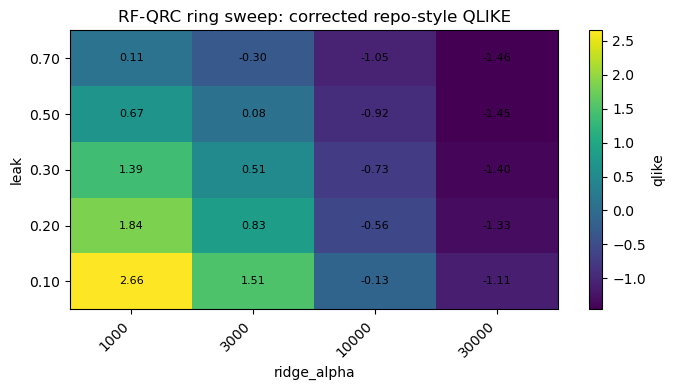

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_qlike_repo_heatmap.png


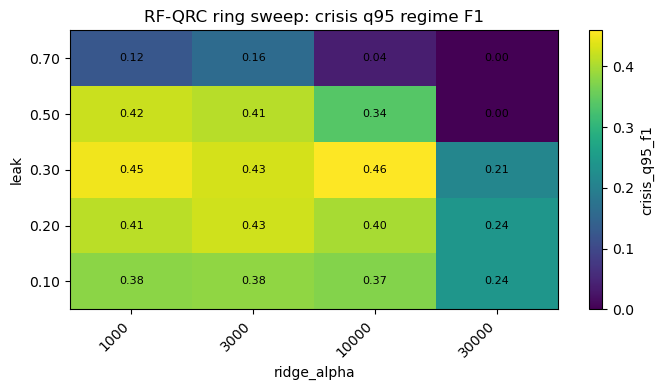

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_crisis_q95_f1_heatmap.png


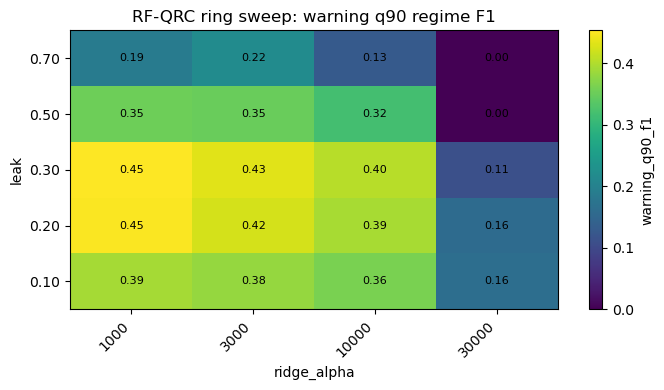

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_warning_q90_f1_heatmap.png


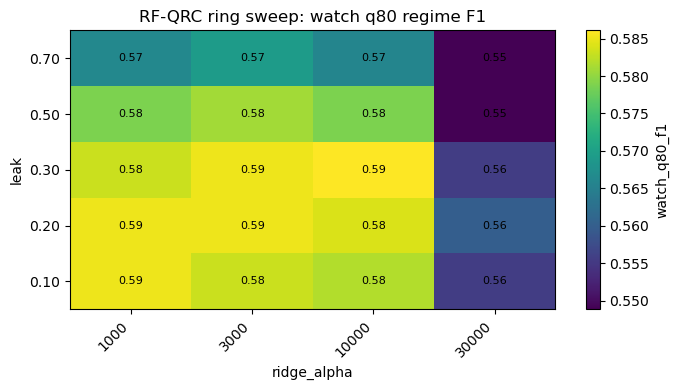

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_watch_q80_f1_heatmap.png


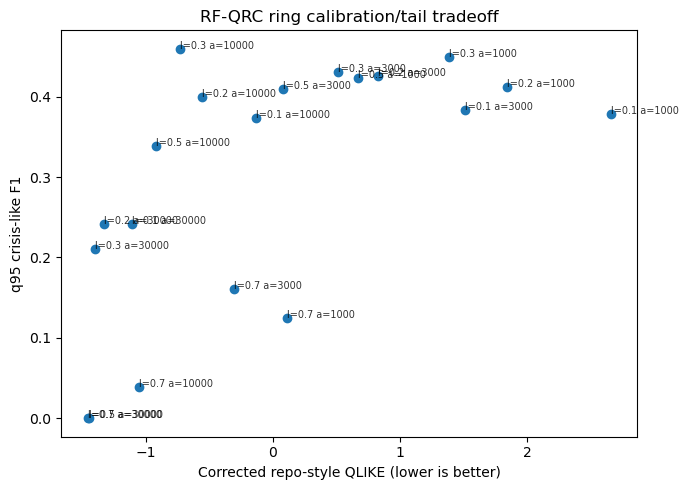

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_qlike_vs_crisis_f1.png


In [11]:
def heatmap_metric(df, metric, title, filename):
    pivot = df.pivot(index="leak", columns="ridge_alpha", values=metric).sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(pivot.values, aspect="auto", origin="lower")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(int(c)) for c in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])
    ax.set_xlabel("ridge_alpha")
    ax.set_ylabel("leak")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=metric)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

heatmap_metric(sweep, "qlike", "RF-QRC ring sweep: corrected repo-style QLIKE", "phase3_rf_qrc_ring_sweep_qlike_repo_heatmap.png")
heatmap_metric(sweep, "crisis_q95_f1", "RF-QRC ring sweep: crisis q95 regime F1", "phase3_rf_qrc_ring_sweep_crisis_q95_f1_heatmap.png")
heatmap_metric(sweep, "warning_q90_f1", "RF-QRC ring sweep: warning q90 regime F1", "phase3_rf_qrc_ring_sweep_warning_q90_f1_heatmap.png")
heatmap_metric(sweep, "watch_q80_f1", "RF-QRC ring sweep: watch q80 regime F1", "phase3_rf_qrc_ring_sweep_watch_q80_f1_heatmap.png")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sweep["qlike"], sweep["crisis_q95_f1"])
for _, r in sweep.iterrows():
    ax.annotate(f"l={r['leak']:.1f} a={int(r['ridge_alpha'])}", (r["qlike"], r["crisis_q95_f1"]), fontsize=7, alpha=0.8)
ax.set_xlabel("Corrected repo-style QLIKE (lower is better)")
ax.set_ylabel("q95 crisis-like F1")
ax.set_title("RF-QRC ring calibration/tail tradeoff")
fig.tight_layout()
out = FIG_DIR / "phase3_rf_qrc_ring_sweep_qlike_vs_crisis_f1.png"
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

## 8. Plot default vs selected candidate

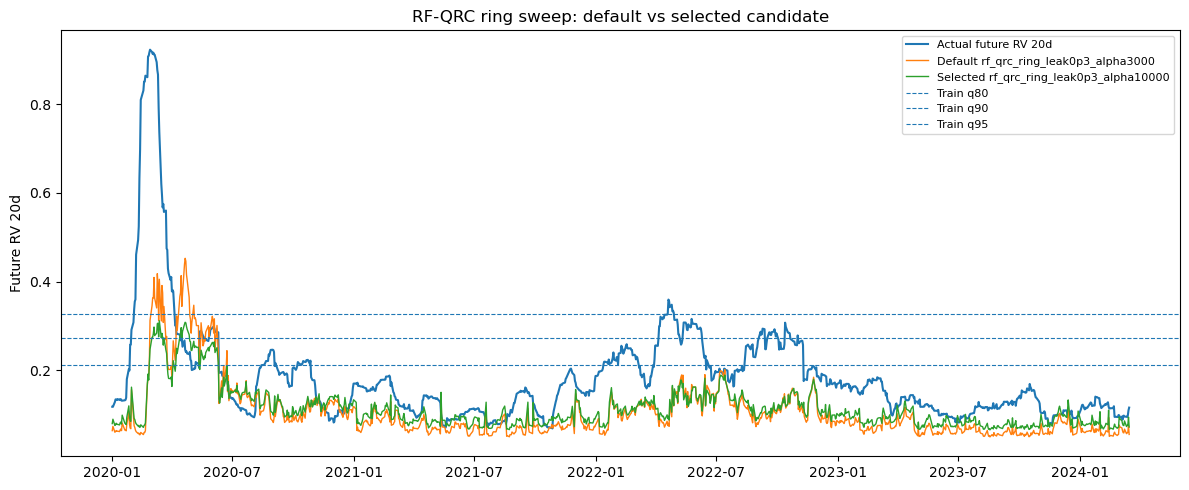

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_default_vs_selected.png
Default: rf_qrc_ring_leak0p3_alpha3000
Selected: rf_qrc_ring_leak0p3_alpha10000


In [12]:
def run_name_for(leak, alpha):
    return f"rf_qrc_ring_leak{str(leak).replace('.', 'p')}_alpha{int(alpha)}"

def pick_best_candidate(sweep):
    # Prefer a guardrail candidate with best corrected QLIKE.
    g = sweep[(sweep["crisis_q95_f1"] >= 0.35) & (sweep["crisis_q95_precision"] >= 0.30) & (sweep["corr"] >= 0.55)].copy()
    if len(g):
        return g.sort_values(["qlike", "crisis_q95_f1"], ascending=[True, False]).iloc[0]["run_name"]
    return sweep.sort_values("selection_score", ascending=False).iloc[0]["run_name"]

default_name = run_name_for(0.30, 3000.0)
best_name = pick_best_candidate(sweep)

plot_cols = ["date", "actual_future_rv_20d", "split", default_name]
if best_name != default_name:
    plot_cols.append(best_name)
plot_df = pred_wide[plot_cols].copy()
plot_df = plot_df[plot_df["split"].eq("test")].merge(timeline[["date"]], on="date", how="inner")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["date"], plot_df["actual_future_rv_20d"], label="Actual future RV 20d", linewidth=1.5)
ax.plot(plot_df["date"], plot_df[default_name], label=f"Default {default_name}", linewidth=1.0)
if best_name != default_name:
    ax.plot(plot_df["date"], plot_df[best_name], label=f"Selected {best_name}", linewidth=1.0)
for label, thr in [("q80", thresholds["high_vol_q80"]), ("q90", thresholds["extreme_vol_q90"]), ("q95", thresholds["crisis_candidate_q95"] )]:
    ax.axhline(thr, linestyle="--", linewidth=0.8, label=f"Train {label}")
ax.set_title("RF-QRC ring sweep: default vs selected candidate")
ax.set_ylabel("Future RV 20d")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
out = FIG_DIR / "phase3_rf_qrc_ring_sweep_default_vs_selected.png"
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)
print("Default:", default_name)
print("Selected:", best_name)

## 9. Saved outputs

In [15]:
print("Total notebook elapsed:", f"{(time.time() - NOTEBOOK_START)/60:.1f} min")
print("Saved tables:")
for p in [sweep_path, pred_path, fixed_path]:
    print(" ", p)
print("Saved figures:")
for name in [
    "phase3_rf_qrc_ring_sweep_qlike_repo_heatmap.png",
    "phase3_rf_qrc_ring_sweep_crisis_q95_f1_heatmap.png",
    "phase3_rf_qrc_ring_sweep_warning_q90_f1_heatmap.png",
    "phase3_rf_qrc_ring_sweep_watch_q80_f1_heatmap.png",
    "phase3_rf_qrc_ring_sweep_qlike_vs_crisis_f1.png",
    "phase3_rf_qrc_ring_sweep_default_vs_selected.png",
]:
    print(" ", FIG_DIR / name)

Total notebook elapsed: 4.0 min
Saved tables:
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_metrics.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_predictions.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_ring_leak_alpha_sweep_metrics_FIXED_QLIKE.csv
Saved figures:
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_qlike_repo_heatmap.png
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_ring_sweep_crisis_q95_f1_